In [1]:
import os
os.chdir('../../../../..')

In [3]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from hdbscan import HDBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid

projection_method = "PCA"

In [4]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["chemprop"])
df = qm9.load()
molecules = qm9.get_molecules()

2026-05-08 10:11:44.866 | INFO     | src.datasets:load:867 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-08 10:11:45.246 | INFO     | src.datasets:_sample_qm9_df:1073 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-05-08 10:11:45.247 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-05-08 10:11:45.247 | INFO     | src.features:compute_chemprop_embeddings:709 - Computing Chemprop embeddings on mps...
2026-05-08 10:11:45.248 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-05-08 10:11:45.248 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt
2026-05-08 10:11:45.295 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-05-08 10:11:45.302 | INFO  

In [5]:
X = np.array(df["chemprop_embedding"].to_list())

In [4]:
for i in range(1000):
    if int(df['num_atoms'].to_list()[i]) != int(len(df['coordinates'].to_list()[i])):
        print(df['mol_id'].to_list()[i])
        break

qm9_567


In [5]:
k=16
df['mol_id'].to_list()[k], df['num_atoms'].to_list()[k], len(df['coordinates'].to_list()[k])

('qm9_540', 16, 16)

In [6]:
len(molecules[0:2])

2

In [7]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [6]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="chemprop",
    dist_type="euclidean",
    force_calculate=True,
    pca_components=6,
)

2026-05-08 10:12:02.422 | INFO     | src.datasets:get_distance_matrix:1479 - Applying PCA to reduce 'chemprop' to 6 dimensions.
2026-05-08 10:12:02.511 | INFO     | src.datasets:get_distance_matrix:1483 - PCA kept 38.87% of the variance for 'chemprop'.
2026-05-08 10:12:02.512 | INFO     | src.datasets:get_distance_matrix:1485 - PCA reduced 'chemprop' dimensions from 2048 to 6
2026-05-08 10:12:02.525 | INFO     | src.datasets:get_distance_matrix:1500 - Calculating distance matrix for chemprop using euclidean distance.
2026-05-08 10:12:02.648 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_chemprop_euclidean_pca6.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:11<00:00,  1.17s/it]


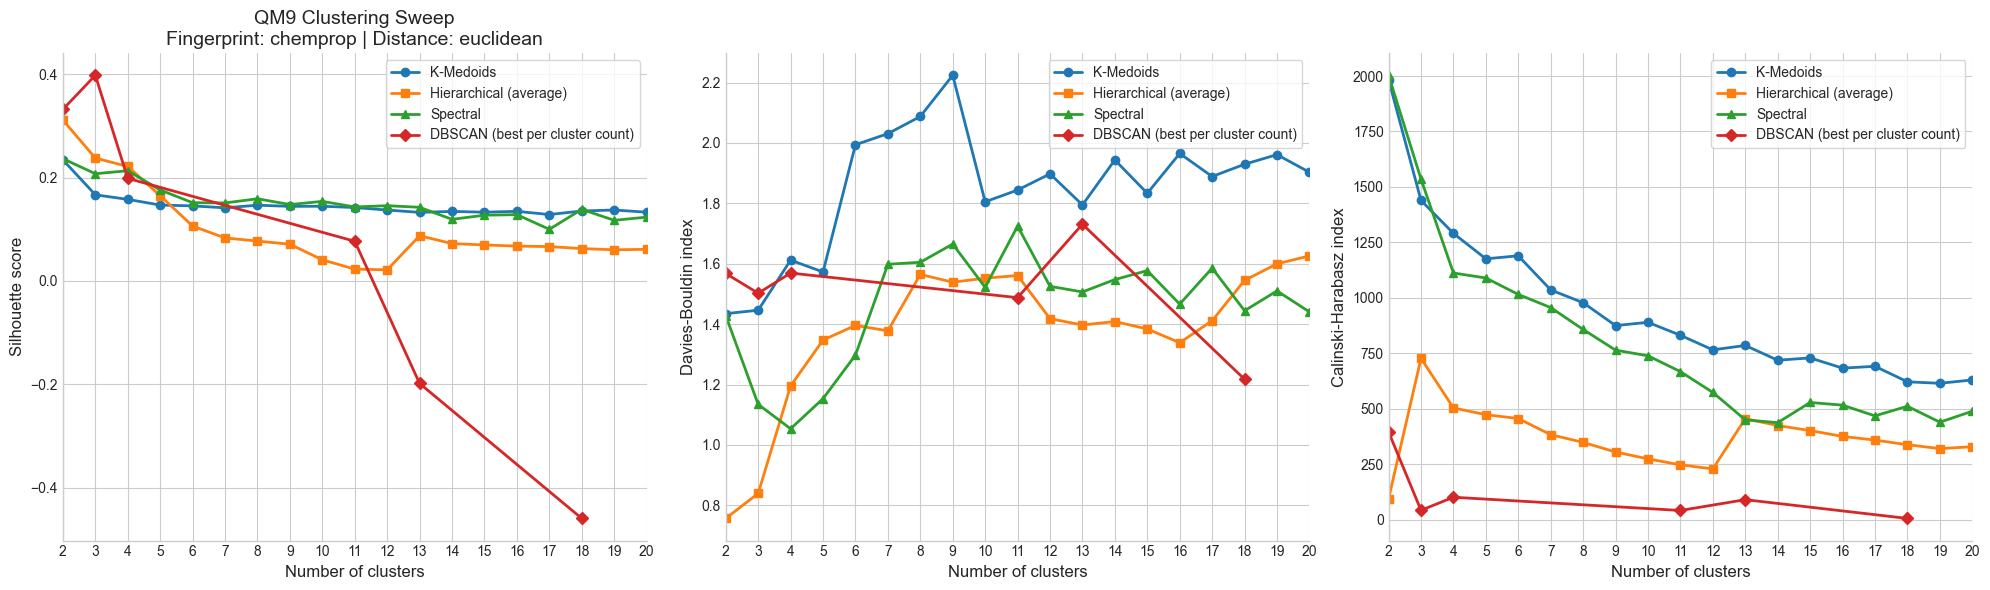

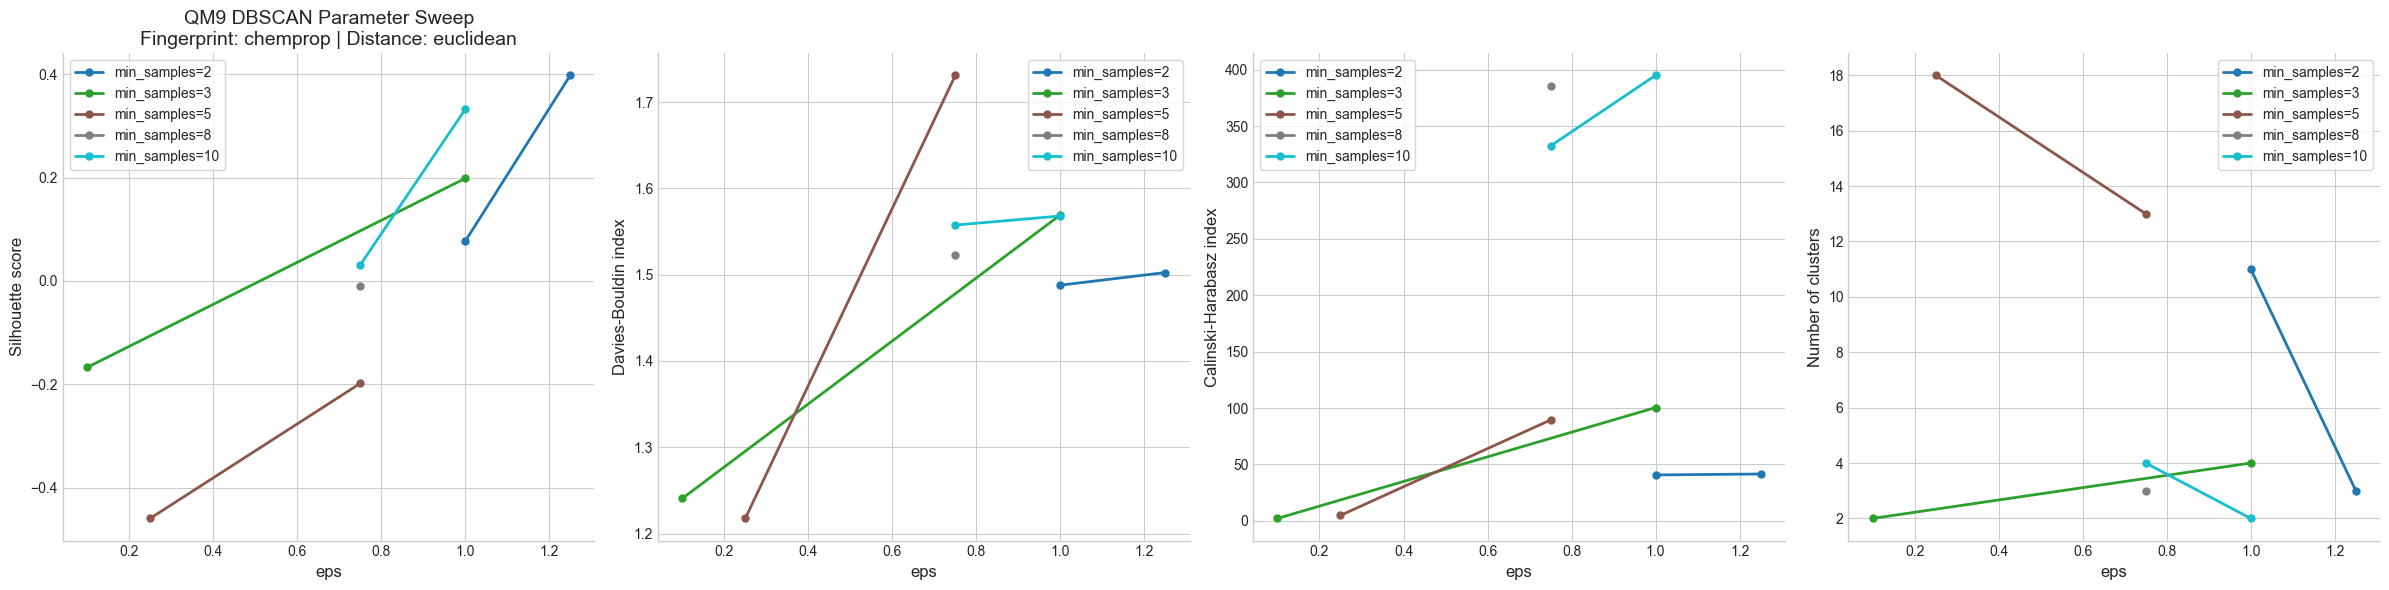

2026-05-07 17:54:31.754 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1060 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/chemprop/clustering_sweep_2_to_20_clusters.png
2026-05-07 17:54:31.756 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1062 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/chemprop/dbscan_parameter_sweep.png
2026-05-07 17:54:31.756 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1063 - Saved clustering sweep results to figures/qm9/clustering/euclidean/chemprop/clustering_sweep_2_to_20_clusters.json


In [9]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [10]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(4856), np.int64(4857)), (np.int64(1234), np.int64(1275)), (np.int64(1197), np.int64(1271)), (np.int64(607), np.int64(717)), (np.int64(3906), np.int64(3907)), (np.int64(3795), np.int64(4425)), (np.int64(4101), np.int64(4142)), (np.int64(194), np.int64(195)), (np.int64(533), np.int64(537)), (np.int64(3196), np.int64(3221))]


In [11]:
print(mols[0])

(Atoms(symbols='NC2OCN2COH5', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='NC2ON2C2OH5', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [12]:
plot_molecules_with_py3dmol(mols[5])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

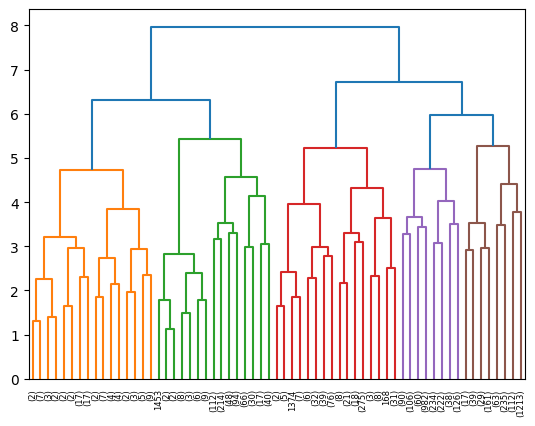

In [7]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=5                
)

In [8]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=5, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

(array([0, 1, 2, 3, 4]), array([ 652, 1869,  533,   88, 1858]))


In [9]:
create_chemiscope_viewer(df, X, labels_hier, 'PCA')

2026-05-08 10:12:16.157 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-08 10:12:16.158 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-08 10:13:08.296 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-08 10:13:08.301 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-08 10:13:08.809 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-08 10:13:08.878 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

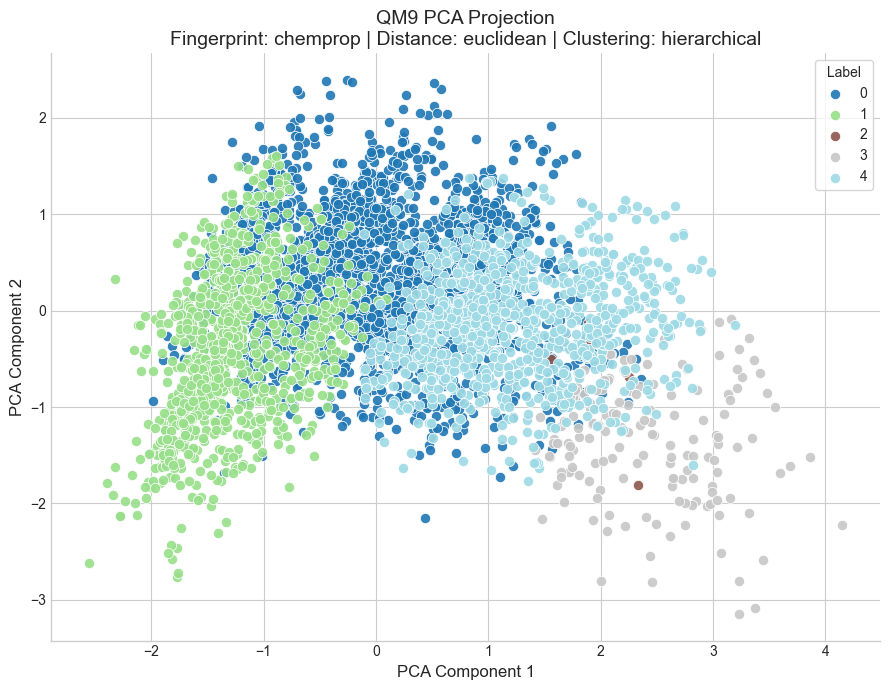

2026-05-07 20:21:00.711 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_hierarchical_projection.png


{'coords': array([[-1.08900603,  1.56179275],
        [-1.30078173,  0.90220092],
        [-0.84682558, -0.39053673],
        ...,
        [-1.51500743, -0.44104594],
        [-1.42309566, -0.00391491],
        [-1.3755275 , -0.25975281]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'hierarchical'}

In [11]:
plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method='PCA',
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [17]:
average_numeric_by_cluster(df, "labels_hier")

shape: (4, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4437,0.742617,0.0,122.939824,0.126662,34.7762,0.880172,12.842647,8.782736,1.63286,0.116971,0.016678,2.329502,18.733153,2.059111,2.405229,0.060352,0.195453,0.744195,0.88686,1.934415,6.606491,0.405229,1.168582,4.879423,6.385621,13.683345,1.261765,0.004057,0.368943,0.021185,0.115844,0.134325,0.001352,0.038314,0.128465,0.566824,0.0,2.630531,75.818384,-6.531103,0.411398,6.942515,1204.201057,4.192865,-11131.128423,-11130.893683,-11130.86799,-11132.042492,32.132179,-77.571488,-78.048335,-78.497179,-72.175187,3.340824,1.386955,1.11165,77.484787,11.697093,10.81812,13.683345,1324,"""Acyclic""",10.81812,296,"""C1CCCC1""",11.088573,1,null,0.0
1,397,0.922354,0.0,120.692695,-0.025189,59.193955,0.621223,12.98845,8.725441,1.098237,0.939547,0.108312,3.987406,13.476071,2.014685,1.410579,0.137409,0.698393,0.164199,0.97733,3.292191,4.874055,0.793451,3.130982,0.813602,6.297229,12.292191,1.265678,0.002519,0.078086,0.161209,0.289673,0.052897,0.002519,0.025189,0.047859,0.211587,0.012594,3.467238,68.729647,-6.526229,-1.06622,5.460078,1120.086393,2.6247,-11817.392052,-11817.186329,-11817.160681,-11818.278318,27.392081,-60.467793,-60.779046,-61.098031,-56.492085,4.650321,1.451467,1.04542,3.526448,84.382872,12.09068,12.292191,161,"""Acyclic""",12.09068,19,"""C1CCCC1""",36.020151,1,null,0.0
2,6,0.946693,0.0,119.666667,0.0,30.666667,1.053708,12.730961,8.5,4.0,0.0,0.0,2.5,16.166667,2.273134,1.5,0.0,0.0,1.0,0.333333,2.5,6.0,0.0,0.0,6.0,5.833333,15.166667,1.287067,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,2.166667,0.0,1.756133,65.829998,-6.741621,1.463066,8.20514,989.232707,3.468118,-11457.390299,-11457.188639,-11457.16276,-11458.255046,28.5115,-67.316423,-67.737415,-68.127208,-62.566218,3.719015,1.797518,1.406565,100.0,0.0,0.0,15.166667,5,"""O1C2C3OC2C13""",33.333333,5,"""C1C2C3CC2C13""",33.333333,1,null,0.0
3,160,0.906542,0.0,121.275,-1.375,23.53125,0.805384,12.811282,8.8375,3.98125,0.0,0.0,2.0875,18.475,2.277292,1.05625,0.0375,0.052426,0.910074,1.625,0.95625,7.75625,0.26875,0.35,6.13125,5.7625,16.6,1.279787,0.0,0.35,0.0,0.14375,0.01875,0.00625,0.0,0.05625,0.15625,0.0,2.363969,73.470375,-6.206611,0.74066,6.947424,939.741851,3.801199,-10631.186658,-10631.000177,-10630.974463,-10632.031561,27.758356,-72.708736,-73.182005,-73.596277,-67.628726,3.541059,1.789392,1.530427,100.0,0.0,0.0,16.6,100,"""C1C2C3C[NH+]2C13""",5.625,55,"""C1CC2C3CC1C23""",14.375,1,null,0.0


# KMedoids

In [10]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)

In [19]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-05-07 18:01:51.369 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 18:01:51.370 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 18:02:49.442 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 18:02:49.447 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 18:02:49.728 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 18:02:49.812 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

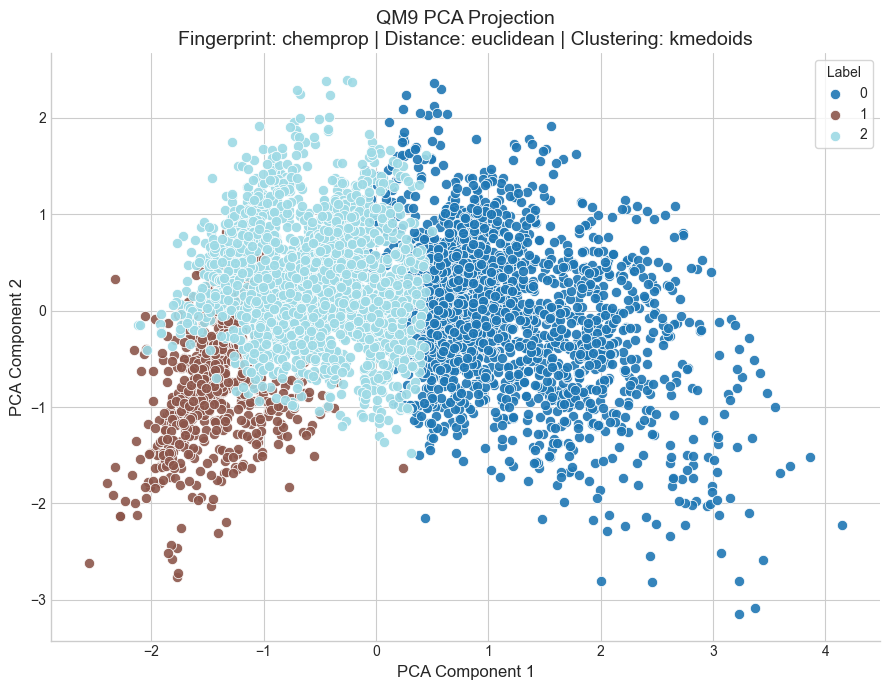

2026-05-07 20:21:56.182 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_kmedoids_projection.png


{'coords': array([[-1.08900603,  1.56179275],
        [-1.30078173,  0.90220092],
        [-0.84682558, -0.39053673],
        ...,
        [-1.51500743, -0.44104594],
        [-1.42309566, -0.00391491],
        [-1.3755275 , -0.25975281]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'kmedoids'}

In [13]:
plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method='PCA',
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [11]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2214,0.799516,0.0,123.003613,-0.032972,28.115176,0.907909,12.789283,8.850949,2.616079,0.008582,0.001355,2.00542,18.999548,2.15248,1.620596,0.032286,0.097851,0.869864,0.868564,1.631888,7.160343,0.225836,0.657633,5.96206,6.044715,14.96477,1.275549,0.0,0.361789,0.0,0.060072,0.075881,0.000903,0.02439,0.117886,0.642276,0.0,2.406335,75.826698,-6.468643,0.785486,7.254182,1082.272835,4.246414,-10973.133398,-10972.916664,-10972.890972,-10974.017327,30.906333,-78.313184,-78.813544,-79.266051,-72.842158,3.134346,1.548523,1.270837,1.988257,99.141825,0.858175,0.0,14.96477,1017,"""C1CC2CC12""",3.387534,283,"""C1CC2CC12""",12.014453,1,null,0.0
1,1072,0.840075,0.0,121.145522,0.033582,53.102612,0.685926,12.966588,8.718284,1.066231,0.761194,0.094216,3.583955,15.058769,2.008358,1.870336,0.095559,0.602767,0.301674,1.06903,2.886194,5.57556,0.564366,3.001866,1.568097,6.410448,12.444963,1.25914,0.011194,0.115672,0.138993,0.286381,0.127799,0.003731,0.039179,0.060634,0.287313,0.004664,3.207091,71.062341,-6.335288,-0.585172,5.750136,1152.986495,3.106287,-11586.568971,-11586.351493,-11586.325826,-11587.468893,28.968185,-65.696024,-66.054111,-66.412199,-61.298985,4.136266,1.419034,1.03771,1.966418,17.070896,72.574627,10.354478,12.444963,352,"""Acyclic""",10.354478,35,"""C1CCCC1""",38.712687,1,null,0.0
2,1714,0.665815,0.0,123.292299,0.215286,36.509918,0.89948,12.864513,8.725788,0.820887,0.033256,0.007585,2.325554,19.436406,1.981073,3.393816,0.09009,0.169234,0.740676,0.884481,1.955076,6.23979,0.613186,1.056009,4.731039,6.729872,12.757876,1.248279,0.004084,0.467328,0.005251,0.123687,0.183781,0.001167,0.049008,0.158693,0.529172,0.0,2.725383,76.886196,-6.703571,0.243645,6.947202,1348.806827,4.400962,-11163.790191,-11163.532737,-11163.507034,-11164.73897,34.175627,-79.589367,-80.071236,-80.538597,-74.025441,3.43336,1.212139,0.977057,2.404317,72.345391,3.325554,24.329055,12.757876,225,"""Acyclic""",24.329055,59,"""Acyclic""",24.329055,1,null,0.0


# Spectral

In [12]:
kernel = np.exp(-dist_matrix**2 / (2 * np.std(dist_matrix)**2))
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(kernel)
df = df.with_columns(labels_spectral=labels_spectral)

In [23]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

2026-05-07 18:09:45.617 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 18:09:45.618 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 18:10:55.915 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 18:10:55.925 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 18:10:56.273 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 18:10:56.369 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

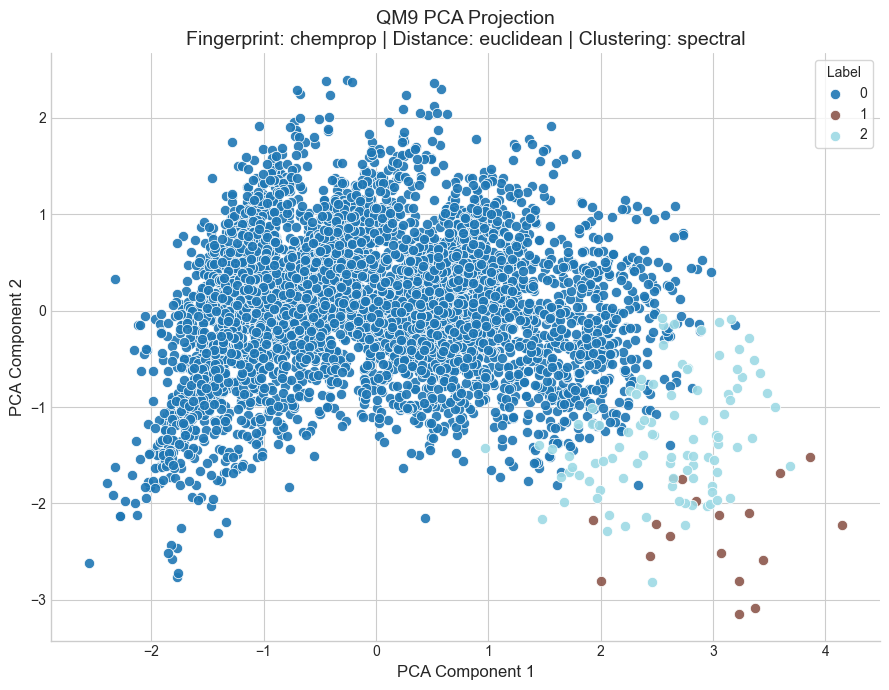

2026-05-08 10:18:09.662 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_spectral_projection.png


{'coords': array([[-1.08900603,  1.56179275],
        [-1.30078173,  0.90220092],
        [-0.84682558, -0.39053673],
        ...,
        [-1.51500743, -0.44104594],
        [-1.42309566, -0.00391491],
        [-1.3755275 , -0.25975281]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'spectral'}

In [13]:
plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method='PCA',
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [25]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_spectral,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4911,0.759091,0.0,122.759927,0.092853,36.649155,0.858285,12.854202,8.780086,1.620037,0.181633,0.023824,2.463449,18.302993,2.058288,2.304622,0.066352,0.23408,0.699568,0.904704,2.035023,6.479332,0.435349,1.315822,4.565465,6.370393,13.605172,1.262352,0.003869,0.345551,0.032173,0.129098,0.126044,0.001629,0.036652,0.120138,0.534922,0.001018,2.697247,75.211989,-6.526956,0.29688,6.823858,1194.20759,4.060871,-11184.228024,-11183.996263,-11183.970573,-11185.138948,31.692872,-76.123341,-76.586762,-77.02466,-70.845813,3.448711,1.395626,1.109935,0.129098,1.019955,71.859092,17.389534,10.751374,13.605172,1478,"""Acyclic""",10.751374,307,"""C1CCCC1""",12.930157,1,null,0.0
1,19,1.00172,0.0,118.842105,-2.157895,26.578947,0.771352,12.814435,8.684211,4.263158,0.0,0.0,2.263158,17.526316,2.352501,0.842105,0.037594,0.02381,0.938596,2.0,0.947368,7.736842,0.263158,0.157895,6.0,5.578947,17.210526,1.281884,0.0,0.421053,0.0,0.368421,0.0,0.0,0.0,0.157895,0.052632,0.0,2.5071,69.91579,-6.087617,0.25149,6.33925,849.01133,3.327845,-10486.674728,-10486.500925,-10486.475098,-10487.503289,26.023631,-66.552065,-66.9787,-67.353377,-61.915839,3.862544,2.044952,1.821062,3.0,0.0,100.0,0.0,0.0,17.210526,14,"""C12C3C1[NH+]1C2C31""",21.052632,12,"""C12C3C1C1C2C31""",21.052632,1,null,0.0
2,70,0.928078,0.0,119.842857,-1.185714,18.028571,0.820557,12.785296,8.771429,4.357143,0.0,0.0,1.814286,18.614286,2.302258,1.085714,0.02517,0.040816,0.934014,1.485714,0.657143,7.971429,0.185714,0.271429,6.5,5.7,17.114286,1.28066,0.0,0.3,0.0,0.157143,0.014286,0.0,0.0,0.071429,0.128571,0.0,2.044496,73.537143,-6.191134,0.951621,7.142833,901.768438,3.836941,-10358.071729,-10357.889146,-10357.863456,-10358.909626,27.419929,-73.164079,-73.644399,-74.060762,-68.063831,3.547022,1.920917,1.646332,2.828571,0.0,100.0,0.0,0.0,17.114286,48,"""C1C2C3C[NH+]2C13""",10.0,28,"""C1C2C3C1C1C2C31""",17.142857,1,null,0.0


# DBSCAN 

In [26]:
model_db = DBSCAN(
    eps=0.08,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23]), array([4952,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
          2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
          2,    2,    2]))


In [27]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-05-07 18:17:15.832 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 18:17:15.833 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 18:18:14.238 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 18:18:14.260 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 18:18:14.559 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 18:18:14.639 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


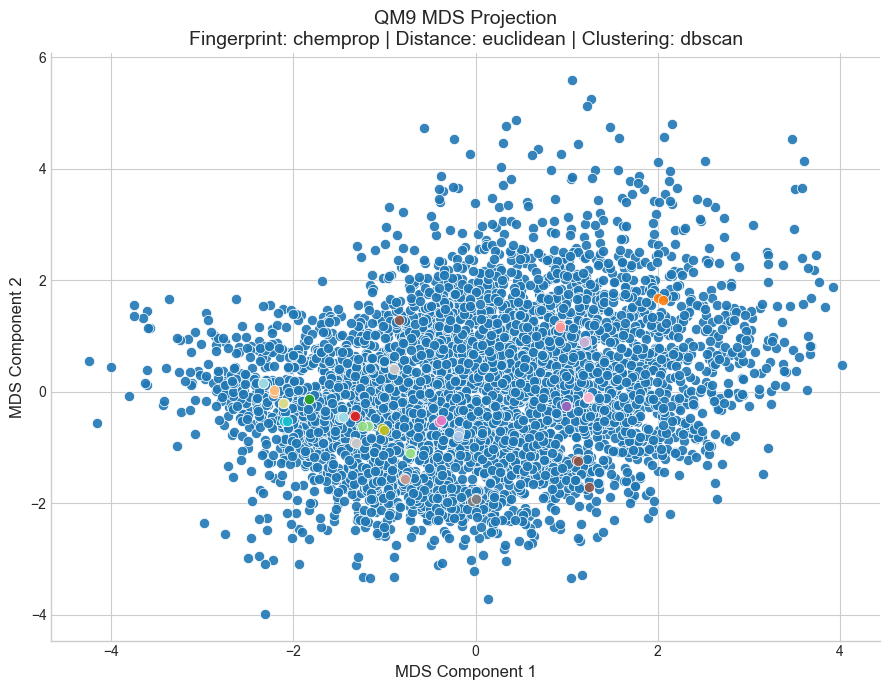

2026-05-07 18:24:39.292 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/euclidean/chemprop/mds_dbscan_projection.png


{'coords': array([[ 0.12607843, -2.54632337],
        [-0.62953247, -1.7407113 ],
        [-0.95958772, -0.04373665],
        ...,
        [-2.01306725, -1.1494947 ],
        [-1.39255618, -1.21766296],
        [-1.55987789, -1.29036775]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/mds_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'dbscan'}

In [28]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [29]:
average_numeric_by_cluster(df, "labels_db")

shape: (25, 74)
┌───────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬───────────┬───────────┬───────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,4952,0.762271,0.0,122.693255,0.063813,36.25101,0.858015,12.852666,8.778675,1.671244,0.174879,0.023223,2.450323,18.309774,2.063103,2.277464,0.066088,0.228251,0.705661,0.91458,2.006462,6.503837,0.434168,1.284733,4.609451,6.356422,13.671244,1.262736,0.003837,0.345315,0.030291,0.128433,0.125202,0.001616,0.036349,0.119144,0.530897,0.00101,2.685566,75.159105,-6.522913,0.311291,6.834226,1188.453063,4.055807,-11167.759809,-11167.528966,-11167.503276,-11168.669412,31.609403,-76.048562,-76.51219,-76.949612,-70.775362,3.452283,1.405862,1.12079,0.177908,1.00101,0.032108,72.6979,16.720517,10.581583,13.671244,1527,"""Acyclic""",10.581583,324,"""C1CCCC1""",12.540388,1,null,0.0
0,2,1.0,0.0,112.0,0.0,69.0,0.68229,12.978272,8.0,1.0,1.0,0.0,4.0,12.0,2.0,2.0,0.0,1.0,0.0,1.0,4.0,5.0,0.0,4.0,0.0,6.0,12.0,1.260659,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.11805,64.735003,-6.163379,-1.537443,4.625936,946.645813,2.303553,-11284.60791,-11284.421875,-11284.396484,-11285.453613,24.7145,-54.875549,-55.152317,-55.434988,-51.345999,6.0982,1.424995,1.15031,1.0,1.0,0.0,0.0,100.0,0.0,12.0,1,"""c1cocn1""",100.0,1,"""C1CCCC1""",100.0,1,null,0.0
1,2,0.666667,0.0,114.0,0.0,37.0,1.002049,12.821232,8.0,1.0,0.0,0.0,2.0,18.0,2.0,2.0,0.0,0.166667,0.833333,1.0,2.0,6.0,0.0,1.0,5.0,5.5,12.0,1.254134,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.28655,67.355,-6.627333,-0.738789,5.888544,945.436096,4.185111,-10475.725098,-10475.505859,-10475.47998,-10476.610352,30.2575,-75.192932,-75.6675,-76.104446,-69.99025,3.1421,1.888625,1.3409,0.0,2.0,0.0,100.0,0.0,0.0,12.0,1,"""O=C1CCCC1""",100.0,1,"""CC1CCCC1""",100.0,1,null,0.0
2,2,0.9375,0.0,112.0,0.0,40.0,1.033031,12.724082,8.0,3.0,0.0,0.0,2.0,16.0,2.25,2.0,0.0,0.0,1.0,2.0,2.0,6.0,0.0,0.0,6.0,6.0,15.0,1.289071,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.2129,63.804998,-6.402839,1.752413,8.156613,795.579285,3.552501,-10440.403809,-10440.213379,-10440.1875,-10441.240234,27.816,-67.098061,-67.52404,-67.909573,-62.426586,3.736635,2.05103,1.704755,0.0,0.0,0.0,100.0,0.0,0.0,15.0,2,"""C1C2C1C1CC21""",50.0,2,"""C1C2C1C1CC21""",50.0,1,null,0.0
3,2,1.0,0.0,126.0,-1.0,97.0,0.362317,13.225756,9.0,1.0,1.0,0.0,5.0,15.0,2.0,2.0,0.0,1.0,0.0,3.0,4.0,7.0,0.0,4.0,0.0,7.0,15.0,1.240985,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,3.1746,75.760002,-5.053154,-0.559194,4.495321,1121.159729,3.146602,-12250.592773,-12250.37793,-12250.352539,-12251.462891,30.748,-65.640362,-66.003677,-66.363449,-61.144699,3.26795,1.412685,0.988935,1.0,1.0,0.0,0.0,100.0,0.0,15.0,2,"""O=c1cncc[nH]1""",50.0,1,"""CC1CCCCC1""",100.0,1,null,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
19,2,0.611111,0.0,127.0,0.0,46.0,0.882372,12.873216,9.0,1.0,1.0,0.0,3.0,18.0,2.0,4.0,0.0,0.5,0.5,1.0,3.0,6.0,0.0,3.0,3.0,7.0,11.0,1.249651,0.0,1

# HDBSCAN

In [17]:
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=220, ms=1, clusters=3, noise=0.29, persistence=0.171, score=0.121
mcs=150, ms=1, clusters=3, noise=0.29, persistence=0.170, score=0.120
mcs=120, ms=1, clusters=3, noise=0.29, persistence=0.167, score=0.118
mcs=300, ms=1, clusters=3, noise=0.29, persistence=0.154, score=0.109
mcs=80, ms=1, clusters=5, noise=0.25, persistence=0.104, score=0.078
mcs=60, ms=10, clusters=2, noise=0.49, persistence=0.090, score=0.046
mcs=80, ms=10, clusters=2, noise=0.49, persistence=0.090, score=0.046
mcs=40, ms=1, clusters=7, noise=0.30, persistence=0.065, score=0.046
mcs=60, ms=1, clusters=7, noise=0.35, persistence=0.068, score=0.045
mcs=120, ms=10, clusters=2, noise=0.49, persistence=0.083, score=0.043
mcs=150, ms=10, clusters=2, noise=0.49, persistence=0.077, score=0.039
mcs=20, ms=2, clusters=27, noise=0.41, persistence=0.061, score=0.036
mcs=40, ms=10, clusters=3, noise=0.48, persistence=0.065, score=0.034
mcs=40, ms=10, clusters=3, noise=0.48, persistence=0.065, score=0.034

In [19]:
clusterer = HDBSCAN(
        min_cluster_size=220,
        min_samples=1,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [32]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-05-07 18:25:32.141 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 18:25:32.142 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 18:26:42.421 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 18:26:42.426 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 18:26:43.866 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 18:26:43.970 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

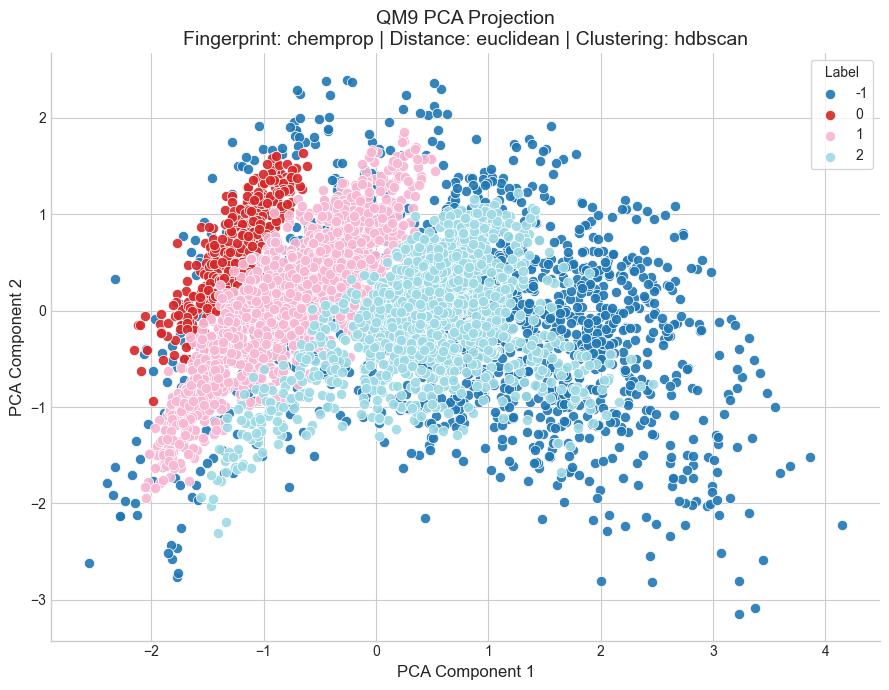

2026-05-07 20:24:25.203 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_hdbscan_projection.png


In [20]:
_=plot_distance_matrix_projection(
    dist_matrix=X,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method='PCA',
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

In [34]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (5, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,2619,0.792256,0.0,122.375716,-0.095838,34.124093,0.853769,12.835152,8.793433,1.967163,0.112638,0.018709,2.346697,18.316533,2.093665,2.057656,0.089199,0.158325,0.752476,0.93929,1.87438,6.516991,0.590302,0.888889,4.967545,6.285605,14.188622,1.266939,0.001909,0.318442,0.008018,0.137457,0.079038,0.001909,0.033982,0.105766,0.571974,0.0,2.625872,75.207289,-6.561295,0.455,7.016336,1163.568497,4.00772,-11056.061933,-11055.834867,-11055.809177,-11056.964858,31.337745,-75.523181,-75.985293,-76.419184,-70.282626,3.499297,1.437337,1.169139,0.255823,0.804506,0.06071,-0.972127,80.030546,10.156548,9.812906,14.188622,1045,"""Acyclic""",9.812906,291,"""C1CC1""",11.225659,1,null,0.0
0,63,0.639083,0.0,118.492063,1.984127,0.0,0.952096,12.687428,8.730159,2.396825,0.0,0.0,0.0,22.460317,2.114051,1.68254,0.0,0.133157,0.866843,0.0,0.0,8.730159,0.0,1.174603,7.555556,6.142857,14.31746,1.265616,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.233513,87.733809,-6.449789,1.40441,7.854156,1156.906913,5.514764,-9271.163481,-9270.93795,-9270.912249,-9272.047937,33.269333,-93.600801,-94.240405,-94.791629,-87.054002,3.065886,1.540085,1.256912,0.0,0.126984,0.0,-1.0,100.0,0.0,0.0,14.31746,47,"""C1CC2CC12""",7.936508,32,"""C1CC2CC2C1""",9.52381,1,null,0.0
1,272,0.631618,0.0,123.658088,0.125,45.6875,0.882966,12.901745,8.691176,0.003676,0.0,0.0,2.702206,18.959559,1.892912,4.797794,0.154937,0.185688,0.659375,0.981618,2.238971,5.430147,1.0,1.022059,3.966912,7.356618,11.838235,1.233518,0.0,0.584559,0.0,0.128676,0.371324,0.0,0.047794,0.191176,0.341912,0.0,3.029789,76.166066,-6.9078,-0.19201,6.71562,1601.897412,4.281927,-11427.197131,-11426.915138,-11426.889438,-11428.194585,35.80154,-78.037566,-78.484524,-78.945002,-72.59907,4.045604,0.92786,0.770378,0.014706,1.966912,0.0,-0.772059,0.367647,0.0,99.632353,11.838235,2,"""Acyclic""",99.632353,2,"""Acyclic""",99.632353,1,null,0.0
2,1243,0.738889,0.0,122.882542,0.188254,45.018504,0.817179,12.921439,8.730491,1.0,0.419147,0.054706,2.954143,17.529364,2.0,2.681416,0.037253,0.429695,0.533052,1.04103,2.445696,6.23572,0.237329,2.305712,3.233307,6.500402,12.647627,1.25364,0.011263,0.356396,0.106195,0.193081,0.181014,0.002414,0.04103,0.116653,0.393403,0.004023,2.930366,73.915969,-6.40028,-0.102948,6.297378,1214.762667,3.872193,-11469.747957,-11469.512022,-11469.486341,-11470.667471,31.6196,-73.906469,-74.341552,-74.763323,-68.818606,3.468546,1.357378,1.01828,0.148029,1.547064,0.0,-0.697506,58.085278,41.914722,0.0,12.647627,213,"""C1CC1""",7.803701,17,"""C1CCCC1""",37.972647,1,null,0.0
3,803,0.755261,0.0,123.506849,0.236613,29.881694,0.91558,12.802287,8.844334,2.235367,0.094645,0.0,2.135741,18.916563,2.113005,1.590286,0.00781,0.180841,0.811349,0.702366,1.867995,7.072229,0.053549,1.16812,5.486924,6.052304,14.118306,1.272446,0.0,0.361146,0.006227,0.021171,0.108344,0.

# KMeans on Raw Embeddings


In [35]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.decomposition import PCA

X = np.array(df['chemprop_embedding'].to_list())
pca = PCA(n_components=4)
X = pca.fit_transform(X)

kmeans = KMeans(n_clusters=3)
labels_kmeans = kmeans.fit_predict(X)
df = df.with_columns(labels_kmeans=labels_kmeans)
print(np.unique(labels_kmeans, return_counts=True))

(array([0, 1, 2], dtype=int32), array([2223,  942, 1835]))


In [36]:
average_numeric_by_cluster(df, 'labels_kmeans')

shape: (3, 76)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2223,0.717649,0.0,123.593342,0.317139,29.984256,0.929306,12.812469,8.808817,1.701305,0.013045,0.00135,2.004948,19.676563,2.066037,2.503374,0.042394,0.124228,0.833377,0.750337,1.77058,6.834458,0.304094,0.841655,5.65812,6.367072,13.879442,1.263117,0.00045,0.447593,0.0,0.040486,0.098965,0.0009,0.02789,0.148448,…,2.45978,77.378574,-6.603293,0.626856,7.230147,1215.789229,4.512136,-11050.113881,-11049.874493,-11049.8488,-11051.030392,33.050086,-81.125693,-81.637683,-82.113078,-75.434118,3.127234,1.370212,1.114476,0.0,0.97076,0.0,-0.937022,0.877643,95.681511,1.304543,3.013945,13.879442,657,"""C1CC1""",9.08682,152,"""C1CC1""",16.059379,1,null,0.0
1,942,0.843343,0.0,122.401274,-0.414013,26.208068,0.870845,12.792468,8.857749,3.18259,0.012739,0.0,1.990446,18.895966,2.207296,1.392781,0.032963,0.064859,0.902179,1.102972,1.409766,7.453291,0.227176,0.432059,6.208068,5.919321,15.711253,1.279232,0.0,0.316348,0.0,0.109342,0.044586,0.002123,0.012739,0.072187,…,2.316749,75.305966,-6.329773,0.966152,7.296028,1024.516388,4.120129,-10814.55636,-10814.350783,-10814.325086,-10815.424282,29.860266,-76.676882,-77.172068,-77.613669,-71.311697,3.216139,1.64966,1.371389,0.522293,0.005308,0.16879,-0.951168,-0.757962,98.726115,1.273885,0.0,15.711253,535,"""C1C[NH+]2CC12""",4.883227,200,"""C1CC2CC12""",10.509554,1,null,0.0
2,1835,0.775003,0.0,121.782561,0.009264,49.268665,0.76346,12.933409,8.704087,0.851226,0.46376,0.062125,3.234877,16.33842,1.984761,2.4703,0.110648,0.444479,0.444873,1.023433,2.612534,5.619074,0.689918,2.292098,2.487193,6.572207,12.362943,1.253661,0.009809,0.235967,0.086104,0.250136,0.195095,0.00218,0.057766,0.108992,…,3.153386,72.420322,-6.518343,-0.421932,6.096421,1240.443917,3.467635,-11497.733198,-11497.499712,-11497.474027,-11498.65579,30.767753,-69.567119,-69.955659,-70.344753,-64.849588,3.965588,1.322768,0.99804,0.216349,1.550954,0.0,-0.774387,0.714441,30.572207,44.305177,25.122616,12.362943,417,"""Acyclic""",25.122616,44,"""C1CCCC1""",28.719346,1,null,0.0


In [37]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

2026-05-07 19:04:30.399 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-07 19:04:30.399 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 19:05:26.364 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-07 19:05:26.377 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-07 19:05:26.686 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 19:05:26.782 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…